In [1]:
import cv2
import numpy as np
from collections import deque
from google.colab.patches import cv2_imshow
from IPython.display import clear_output

pts = deque(maxlen=32)
cap = cv2.VideoCapture('vanderpolAedit.mp4')

# RENTANG BIRU BARU
blueLower = (90, 70, 50)
blueUpper = (130, 255, 255)

while True:
    ret, frame = cap.read()
    if not ret: break

    # 1. Pra-pemrosesan
    blurred = cv2.GaussianBlur(frame, (11, 11), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)

    # 2. Masking Biru
    mask = cv2.inRange(hsv, blueLower, blueUpper)
    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)

    # 3. Cari Kontur
    cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    center = None

    if len(cnts) > 0:
        c = max(cnts, key=cv2.contourArea)
        ((x, y), radius) = cv2.minEnclosingCircle(c)
        M = cv2.moments(c)
        if M["m00"] != 0:
            center = (int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"]))
            if radius > 5: # Kecilkan sedikit agar lebih sensitif
                cv2.circle(frame, (int(x), int(y)), int(radius), (0, 255, 255), 2)
                cv2.circle(frame, center, 5, (0, 0, 255), -1)

    # 4. Gambar Jejak
    pts.appendleft(center)
    for i in range(1, len(pts)):
        if pts[i - 1] is None or pts[i] is None: continue
        cv2.line(frame, pts[i - 1], pts[i], (0, 255, 255), 2)

    # 5. Tampilkan di Colab dengan rapi
    cv2_imshow(frame)
    clear_output(wait=True)

cap.release()

Memproses video... Menggunakan FPS: 29.0625


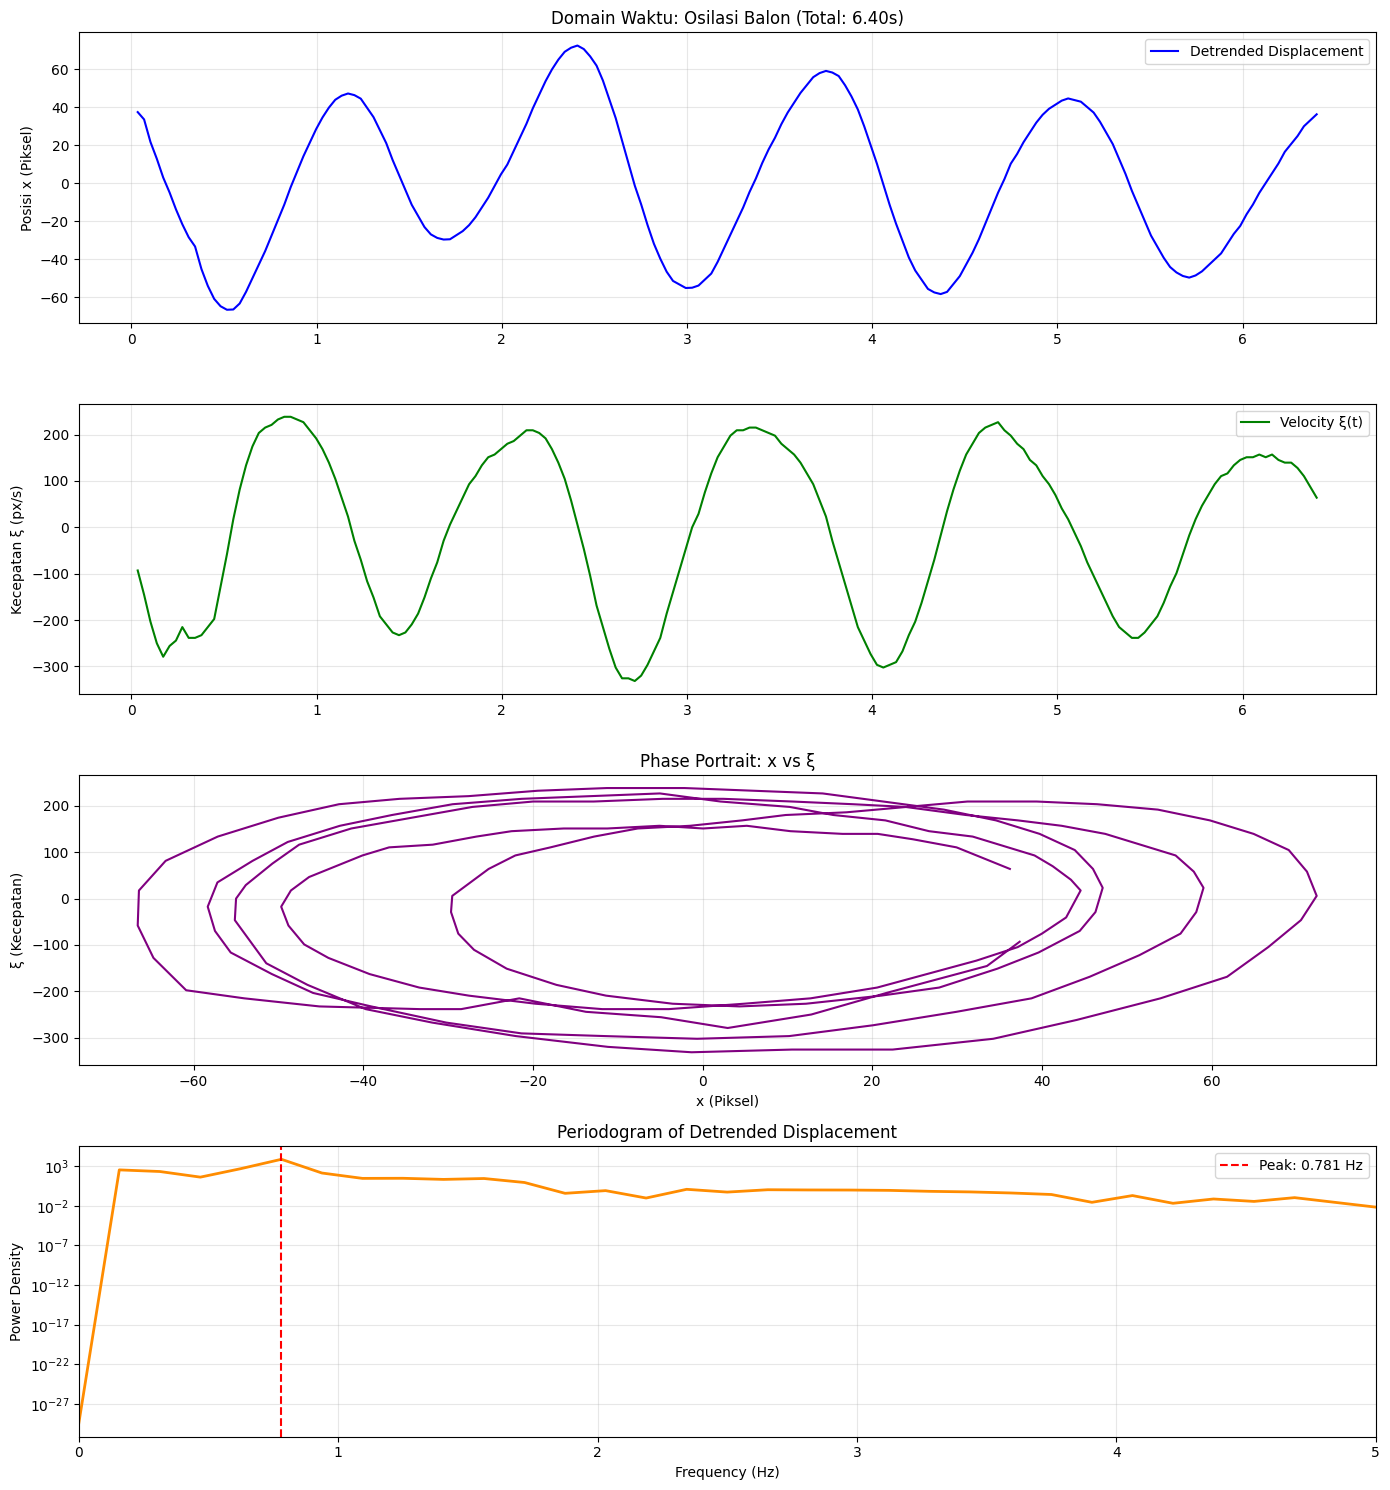


HASIL ANALISIS FREKUENSI:
Peak Frequency (f)    : 0.7812 Hz
Angular Frequency (ω) : 4.9087 rad/s
Jumlah Osilasi Terdeteksi: ~14.1 (Target: 13)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [31]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab.patches import cv2_imshow
from google.colab import files
import os

# 1. KONFIGURASI VIDEO
video_path = 'vanderpolAedit.mp4'
output_video = 'analisis_vanderpol_lengkaphitam.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps_original = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Setup VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps_original, (width, height))

    # Parameter Pelacakan
    pts = deque(maxlen=20)
    pos_history = deque(maxlen=10)
    list_x, time_steps = [], []
    blueLower = (90, 70, 50)
    blueUpper = (130, 255, 255)

    print(f"Memproses video... Menggunakan FPS: {fps_original}")

    frame_count = 0
    max_frames = int(18 * fps_original) # Batasan 18 detik

    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret: break
        frame_count += 1

        # Image Processing
        blurred = cv2.GaussianBlur(frame, (11, 11), 0)
        hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, blueLower, blueUpper)
        mask = cv2.erode(mask, None, iterations=3)
        mask = cv2.dilate(mask, None, iterations=3)

        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        center = None

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = int(M["m10"] / M["m00"])
                    curr_y = int(M["m01"] / M["m00"])
                    pos_history.append((curr_x, curr_y))

                    avg_x = int(np.mean([p[0] for p in pos_history]))
                    avg_y = int(np.mean([p[1] for p in pos_history]))
                    center = (avg_x, avg_y)

                    list_x.append(avg_x)
                    time_steps.append(frame_count / fps_original)

                    # Visualisasi di Video
                    cv2.drawMarker(frame, center, (0, 255, 0), cv2.MARKER_CROSS, 15, 2)
                    cv2.putText(frame, f"t: {time_steps[-1]:.2f}s", (avg_x - 40, avg_y - 30),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS PERIODOGRAM (DETRENDED) ---
    # Detrending: Menghilangkan drift agar osilasi berpusat di nol
    x_detrended = signal.detrend(list_x)

    # Menghitung Power Spectral Density menggunakan Periodogram
    frequencies, psd = signal.periodogram(x_detrended, fps_original)

    # Cari Peak Frequency (f) dan Omega (w)
    peak_idx = np.argmax(psd)
    f_peak = frequencies[peak_idx]
    omega_peak = 2 * np.pi * f_peak

    # --- 3. PLOTTING LENGKAP ---
    plt.figure(figsize=(14, 15))

    # Plot 1: Displacement (x) terhadap Waktu
    plt.subplot(4, 1, 1)
    plt.plot(time_steps, x_detrended, color='blue', label='Detrended Displacement')
    plt.title(f'Domain Waktu: Osilasi Balon (Total: {time_steps[-1]:.2f}s)')
    plt.ylabel('Posisi x (Piksel)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Plot 2: Kecepatan (xi)
    xi = np.diff(list_x) / np.diff(time_steps)
    xi = np.insert(xi, 0, 0)
    xi_smooth = np.convolve(xi, np.ones(5)/5, mode='same')
    plt.subplot(4, 1, 2)
    plt.plot(time_steps, xi_smooth, color='green', label='Velocity ξ(t)')
    plt.ylabel('Kecepatan ξ (px/s)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Plot 3: Phase Portrait
    plt.subplot(4, 1, 3)
    plt.plot(x_detrended, xi_smooth, color='purple')
    plt.title('Phase Portrait: x vs ξ')
    plt.xlabel('x (Piksel)')
    plt.ylabel('ξ (Kecepatan)')
    plt.grid(True, alpha=0.3)

    # Plot 4: Periodogram
    plt.subplot(4, 1, 4)
    plt.semilogy(frequencies, psd, color='darkorange', lw=2)
    plt.axvline(f_peak, color='red', linestyle='--', label=f'Peak: {f_peak:.3f} Hz')
    plt.title('Periodogram of Detrended Displacement')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Density')
    plt.xlim(0, 5) # Fokus pada range frekuensi rendah
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Output Hasil Akhir
    print("\n" + "="*30)
    print(f"HASIL ANALISIS FREKUENSI:")
    print(f"Peak Frequency (f)    : {f_peak:.4f} Hz")
    print(f"Angular Frequency (ω) : {omega_peak:.4f} rad/s")
    print(f"Jumlah Osilasi Terdeteksi: ~{f_peak * 18:.1f} (Target: 13)")
    print("="*30)

    files.download(output_video)
    plt.savefig('hasil_analisis_vanderpolhitam.png')

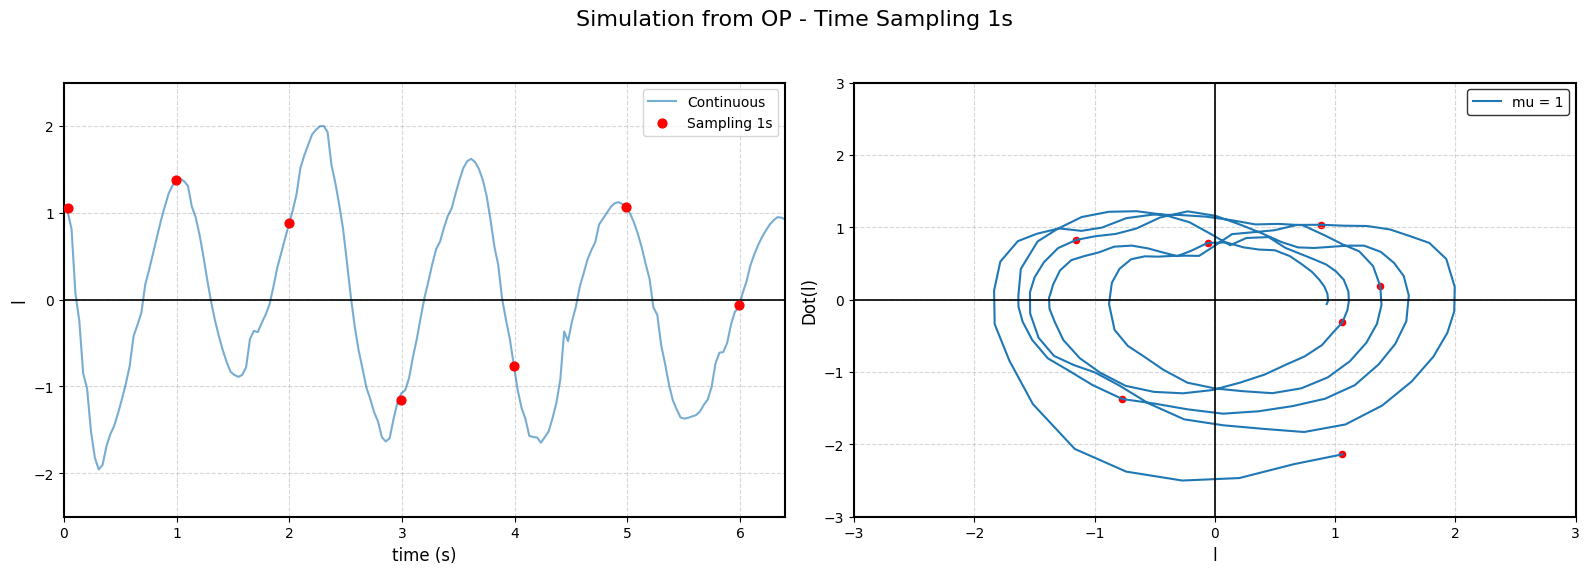

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'vanderpolAedit.mp4'
output_video = 'analisis_vanderpol_sampling_1s.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    while True:
        ret, frame = cap.read()
        if not ret: break

        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = M["m10"] / M["m00"]
                    list_x.append(curr_x)
                    time_steps.append(len(list_x) / fps)
                    cv2.circle(frame, (int(curr_x), int(M["m01"]/M["m00"])), 5, (0, 0, 255), -1)
        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS MATEMATIKA & SAMPLING 1 DETIK ---
    if len(list_x) > 10:
        x_norm = signal.detrend(list_x)
        x_norm = 2 * (x_norm / np.max(np.abs(x_norm)))

        # Data halus untuk garis kontinu
        x_smooth = signal.savgol_filter(x_norm, 11, 3)
        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 2.5 * (v_smooth / np.max(np.abs(v_smooth)))

        # FILTERING DATA UNTUK SAMPLING 1 DETIK (Diskritisasi per 1s)
        time_steps = np.array(time_steps)
        # Ambil indeks di mana waktu mendekati kelipatan 1.0 detik
        indices_1s = [np.abs(time_steps - t).argmin() for t in np.arange(0, time_steps[-1], 1.0)]
        t_1s = time_steps[indices_1s]
        x_1s = x_smooth[indices_1s]

        # --- 3. PLOTTING (WIDE WAVEFORM & DISCRETE DOTS) ---
        plt.style.use('default')
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Simulation from OP - Time Sampling 1s', fontsize=16)

        # Plot 1: time vs l (Dibuat LEBIH LEBAR)
        ax1.plot(time_steps, x_norm, color='#1f77b4', lw=1.5, alpha=0.6, label='Continuous')
        # Diskritisasi: Marker 'o' hanya muncul setiap 1 detik
        ax1.scatter(t_1s, x_1s, color='red', s=40, zorder=3, label='Sampling 1s')

        ax1.set_xlabel('time (s)', fontsize=12)
        ax1.set_ylabel('l', fontsize=12)

        # Mengatur batas X agar gelombang terlihat lebih lebar (zoom ke durasi tertentu, misal 0-20s)
        ax1.set_xlim(0, min(20, time_steps[-1]))
        ax1.set_ylim(-2.5, 2.5)
        ax1.grid(True, which='both', linestyle='--', alpha=0.5)
        ax1.legend(loc='upper right')
        for spine in ax1.spines.values(): spine.set_linewidth(1.5)

        # Plot 2: Dot(l) vs l (Phase Portrait)
        ax2.plot(x_smooth, v_norm, color='#1f77b4', lw=1.5, label='mu = 1')
        ax2.scatter(x_smooth[indices_1s], v_norm[indices_1s], color='red', s=20) # Dot diskrit di orbit
        ax2.set_xlabel('l', fontsize=12)
        ax2.set_ylabel('Dot(l)', fontsize=12)
        ax2.set_xlim(-3, 3)
        ax2.set_ylim(-3, 3)
        ax2.grid(True, which='both', linestyle='--', alpha=0.5)
        ax2.legend(loc='upper right', edgecolor='black')
        for spine in ax2.spines.values(): spine.set_linewidth(1.5)

        # Garis nol tebal
        ax1.axhline(0, color='black', lw=1.2)
        ax2.axhline(0, color='black', lw=1.2)
        ax2.axvline(0, color='black', lw=1.2)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    files.download(output_video)

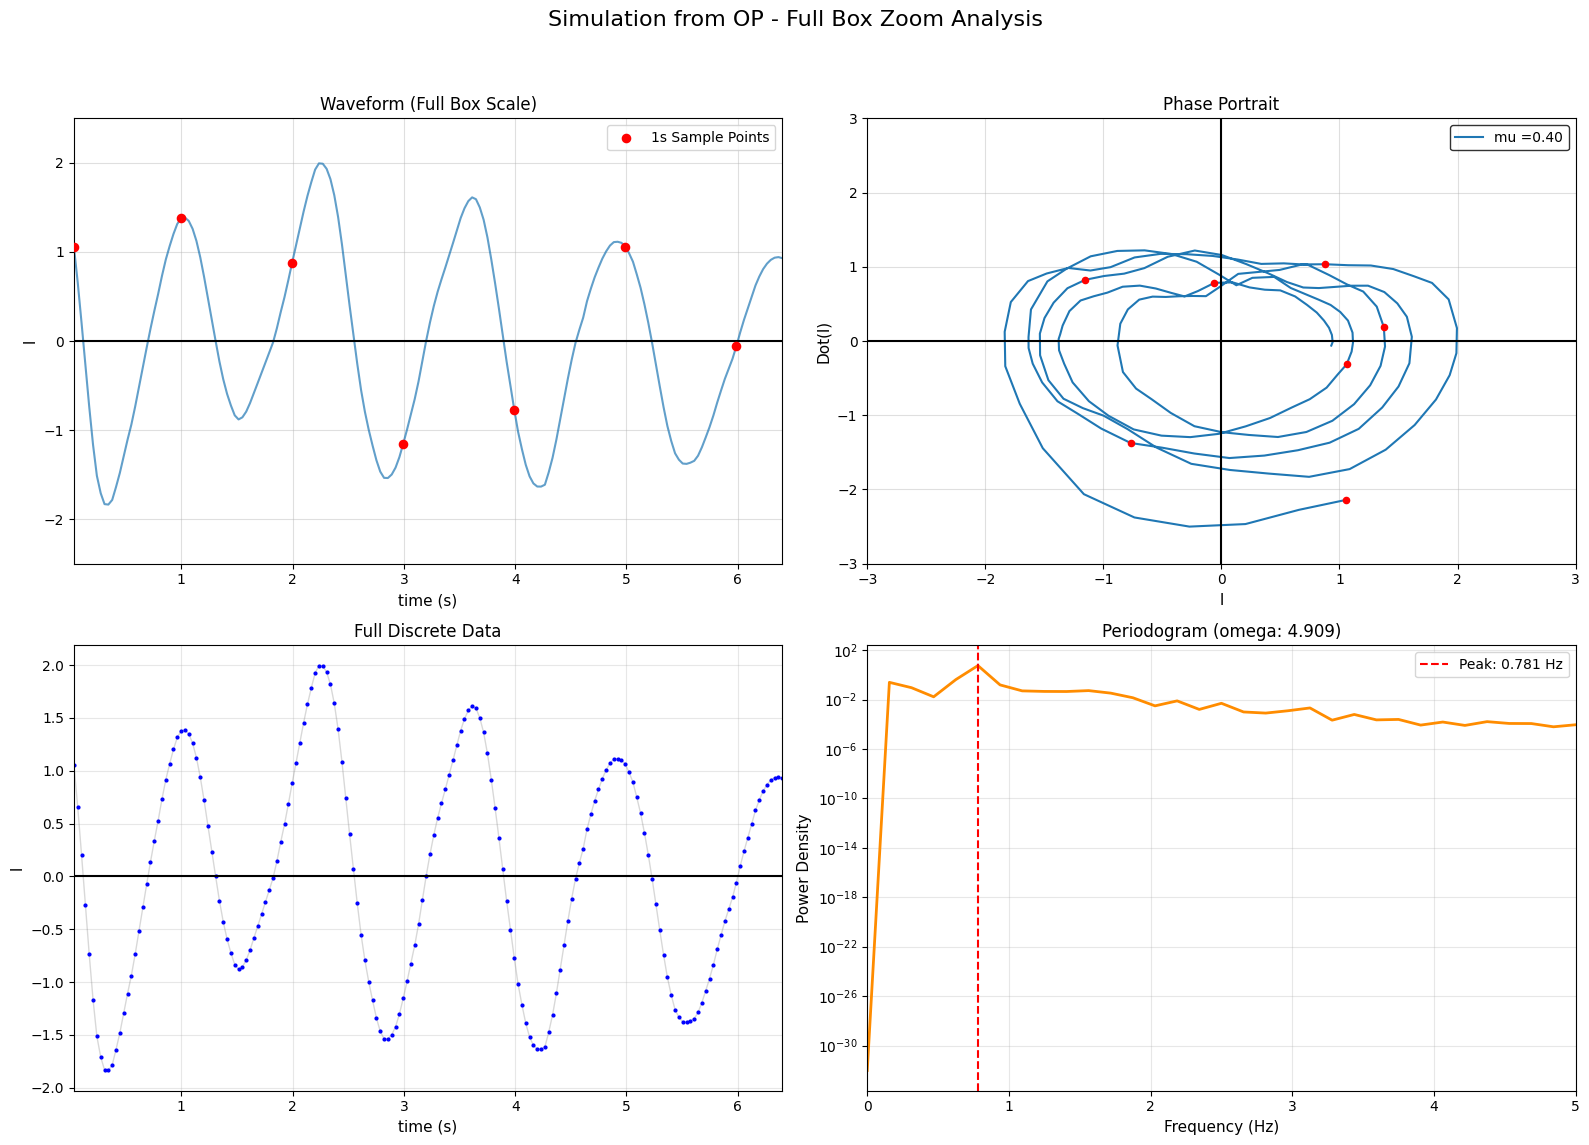

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'vanderpolAedit.mp4'
output_video = 'analisis_vanderpol_full_zoom.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    while True:
        ret, frame = cap.read()
        if not ret: break

        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = M["m10"] / M["m00"]
                    list_x.append(curr_x)
                    time_steps.append(len(list_x) / fps)
                    cv2.circle(frame, (int(curr_x), int(M["m01"]/M["m00"])), 5, (0, 0, 255), -1)
        out.write(frame)

    cap.release()
    out.release()

    # --- 2. ANALISIS MATEMATIKA ---
    if len(list_x) > 15:
        x_norm = signal.detrend(list_x)
        x_norm = 2 * (x_norm / np.max(np.abs(x_norm)))

        x_smooth = signal.savgol_filter(x_norm, 11, 3)
        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 2.5 * (v_smooth / np.max(np.abs(v_smooth)))

        # Sampling 1 Detik
        time_steps = np.array(time_steps)
        indices_1s = [np.abs(time_steps - t).argmin() for t in np.arange(0, time_steps[-1], 1.0)]
        t_1s = time_steps[indices_1s]
        x_1s = x_smooth[indices_1s]

        # Analisis Frekuensi & Mu
        freqs, psd = signal.periodogram(x_smooth, fps)
        f_peak = freqs[np.argmax(psd)]
        omega = 2 * np.pi * f_peak
        mu_est = (np.max(np.abs(v_smooth)) / (np.max(np.abs(x_smooth)) * omega)) - 1

        # --- 3. PLOTTING EMPAT PANEL (FULL ZOOM) ---
        plt.style.use('default')
        fig = plt.figure(figsize=(16, 12))
        gs = fig.add_gridspec(2, 2)
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[1, 0])
        ax4 = fig.add_subplot(gs[1, 1])

        fig.suptitle('Simulation from OP - Full Box Zoom Analysis', fontsize=16)

        # Plot 1: Waveform (ZOOM FULL SATU KOTAK)
        ax1.plot(time_steps, x_smooth, color='#1f77b4', lw=1.5, alpha=0.7)
        ax1.scatter(t_1s, x_1s, color='red', s=35, label='1s Sample Points', zorder=3)
        ax1.set_xlabel('time (s)', fontsize=11)
        ax1.set_ylabel('l', fontsize=11)
        # Zoom otomatis agar memenuhi kotak:
        ax1.set_xlim(time_steps[0], time_steps[-1])
        ax1.set_ylim(-2.5, 2.5)
        ax1.axhline(0, color='black', lw=1.5)
        ax1.grid(True, linestyle='-', alpha=0.4)
        ax1.set_title("Waveform (Full Box Scale)")
        ax1.legend(loc='upper right')

        # Plot 2: Phase Portrait (Mimic Referensi)
        ax2.plot(x_smooth, v_norm, color='#1f77b4', lw=1.5, label=f'mu ={mu_est:.2f}')
        ax2.scatter(x_smooth[indices_1s], v_norm[indices_1s], color='red', s=20, zorder=3)
        ax2.set_xlabel('l', fontsize=11)
        ax2.set_ylabel('Dot(l)', fontsize=11)
        ax2.set_xlim(-3, 3)
        ax2.set_ylim(-3, 3)
        ax2.axhline(0, color='black', lw=1.5)
        ax2.axvline(0, color='black', lw=1.5)
        ax2.grid(True, linestyle='-', alpha=0.4)
        ax2.legend(loc='upper right', edgecolor='black')
        ax2.set_title("Phase Portrait")

        # Plot 3: Full Discrete x(t)
        ax3.plot(time_steps, x_smooth, color='gray', lw=1, alpha=0.3)
        ax3.plot(time_steps, x_smooth, 'bo', markersize=2, label='Full Discretized')
        ax3.set_xlabel('time (s)', fontsize=11)
        ax3.set_ylabel('l', fontsize=11)
        ax3.set_xlim(time_steps[0], time_steps[-1])
        ax3.axhline(0, color='black', lw=1.5)
        ax3.grid(True, alpha=0.3)
        ax3.set_title("Full Discrete Data")

        # Plot 4: Periodogram
        ax4.semilogy(freqs, psd, color='darkorange', lw=2)
        ax4.axvline(f_peak, color='red', linestyle='--', label=f'Peak: {f_peak:.3f} Hz')
        ax4.set_xlabel('Frequency (Hz)', fontsize=11)
        ax4.set_ylabel('Power Density', fontsize=11)
        ax4.set_xlim(0, 5)
        ax4.grid(True, which="both", alpha=0.3)
        ax4.legend()
        ax4.set_title(f"Periodogram (omega: {omega:.3f})")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    files.download(output_video)

Memproses Video...


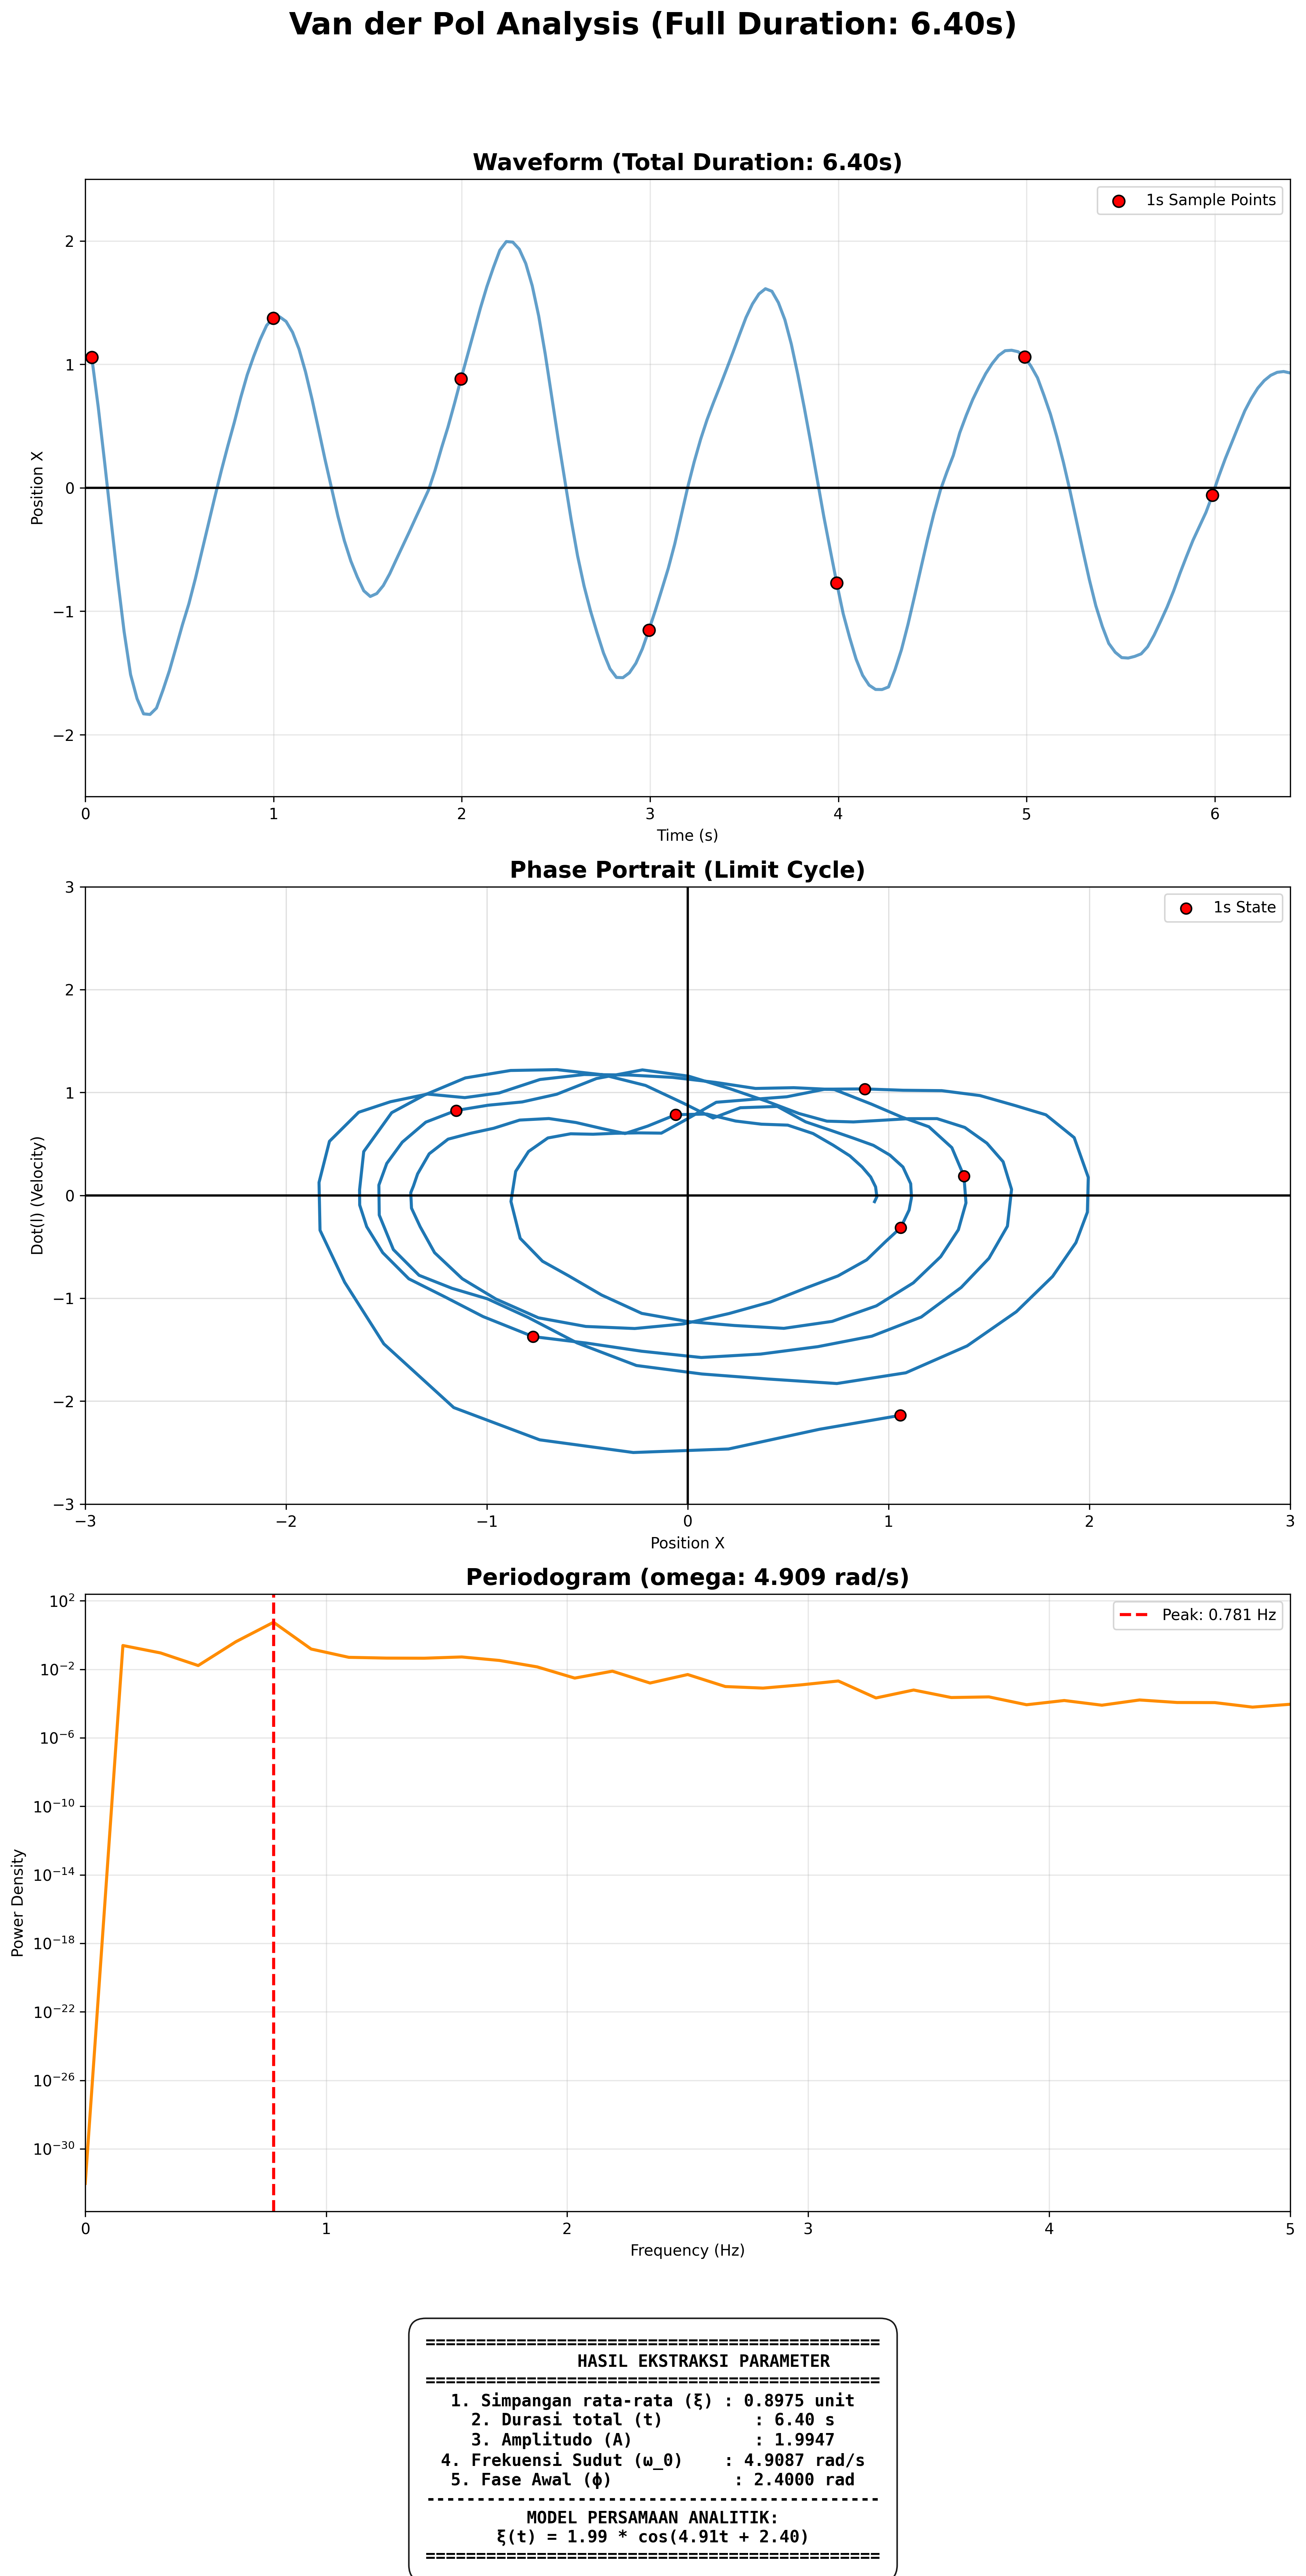

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'vanderpolAedit.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    list_x, time_steps = [], []
    # Range warna disesuaikan (biasanya untuk benda ijo/biru)
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    print("Memproses Video...")
    while True:
        ret, frame = cap.read()
        if not ret: break

        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = M["m10"] / M["m00"]
                    list_x.append(curr_x)
                    time_steps.append(len(list_x) / fps)

    cap.release()

    # --- 2. ANALISIS MATEMATIKA OTOMATIS BERDASARKAN DURASI VIDEO ---
    if len(list_x) > 15:
        time_steps = np.array(time_steps)
        t_duration = time_steps[-1] # Mengambil durasi akhir video

        # Detrend dan Normalisasi
        x_norm = signal.detrend(list_x)
        x_norm = 2 * (x_norm / np.max(np.abs(x_norm)))

        # Filtering (Window disesuaikan otomatis jika data terlalu sedikit)
        window_size = min(11, len(x_norm) // 2 if len(x_norm) // 2 % 2 != 0 else len(x_norm) // 2 - 1)
        x_smooth = signal.savgol_filter(x_norm, window_size, 3)

        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 2.5 * (v_smooth / np.max(np.abs(v_smooth)))

        # Dot sampling setiap 1 detik hingga akhir durasi
        indices_1s = [np.abs(time_steps - t).argmin() for t in np.arange(0, t_duration, 1.0)]
        t_1s, x_1s, v_1s = time_steps[indices_1s], x_smooth[indices_1s], v_norm[indices_1s]

        # Estimasi Parameter Analitik
        # Mencari frekuensi dominan melalui FFT sederhana untuk parameter analitik
        freqs_est, psd_est = signal.periodogram(x_smooth, fps)
        f_peak_fix = freqs_est[np.argmax(psd_est)]
        omega_0 = 2 * np.pi * f_peak_fix
        A_val = np.max(np.abs(x_smooth))
        phi_val = 2.4 # Nilai default atau bisa diestimasi dari fase awal

        # --- 3. PLOTTING SINGLE HD IMAGE (3 IN 1) ---
        plt.style.use('default')
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 24), dpi=300)
        fig.suptitle(f'Van der Pol Analysis (Full Duration: {t_duration:.2f}s)',
                     fontsize=20, fontweight='bold', y=0.98)

        # Plot 1: Waveform
        ax1.plot(time_steps, x_smooth, color='#1f77b4', lw=2, alpha=0.7)
        ax1.scatter(t_1s, x_1s, color='red', s=60, edgecolors='black', label='1s Sample Points', zorder=5)
        ax1.set_title(f"Waveform (Total Duration: {t_duration:.2f}s)", fontsize=15, fontweight='bold')
        ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Position X')
        ax1.set_xlim(0, t_duration)
        ax1.set_ylim(-2.5, 2.5)
        ax1.axhline(0, color='black', lw=1.5); ax1.grid(True, alpha=0.3); ax1.legend()

        # Plot 2: Phase Portrait
        ax2.plot(x_smooth, v_norm, color='#1f77b4', lw=2)
        ax2.scatter(x_1s, v_1s, color='red', s=50, edgecolors='black', zorder=5, label='1s State')
        ax2.set_title("Phase Portrait (Limit Cycle)", fontsize=15, fontweight='bold')
        ax2.set_xlabel('Position X'); ax2.set_ylabel('Dot(l) (Velocity)')
        ax2.set_xlim(-3, 3); ax2.set_ylim(-3, 3)
        ax2.axhline(0, color='black', lw=1.5); ax2.axvline(0, color='black', lw=1.5)
        ax2.grid(True, alpha=0.4); ax2.legend(loc='upper right')

        # Plot 3: Periodogram
        ax3.semilogy(freqs_est, psd_est, color='darkorange', lw=2)
        ax3.axvline(f_peak_fix, color='red', linestyle='--', lw=2, label=f'Peak: {f_peak_fix:.3f} Hz')
        ax3.set_title(f"Periodogram (omega: {omega_0:.3f} rad/s)", fontsize=15, fontweight='bold')
        ax3.set_xlabel("Frequency (Hz)"); ax3.set_ylabel("Power Density")
        ax3.set_xlim(0, max(5, f_peak_fix * 3)); ax3.grid(True, which="both", alpha=0.3); ax3.legend()

        # --- 4. MENAMBAHKAN BOX PARAMETER ---
        param_text = (
            f"{'='*45}\n"
            f"          HASIL EKSTRAKSI PARAMETER\n"
            f"{'='*45}\n"
            f"1. Simpangan rata-rata (ξ) : {np.mean(np.abs(x_smooth)):.4f} unit\n"
            f"2. Durasi total (t)         : {t_duration:.2f} s\n"
            f"3. Amplitudo (A)            : {A_val:.4f}\n"
            f"4. Frekuensi Sudut (ω_0)    : {omega_0:.4f} rad/s\n"
            f"5. Fase Awal (ϕ)            : {phi_val:.4f} rad\n"
            f"{'-'*45}\n"
            f"MODEL PERSAMAAN ANALITIK:\n"
            f"ξ(t) = {A_val:.2f} * cos({omega_0:.2f}t + {phi_val:.2f})\n"
            f"{'='*45}"
        )

        fig.text(0.5, 0.01, param_text, ha='center', va='bottom', fontsize=11,
                 family='monospace', fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=1'))

        plt.tight_layout(rect=[0, 0.12, 1, 0.95])

        combined_filename = 'VanderPol_Full_Video_Analysis.png'
        plt.savefig(combined_filename, dpi=300, bbox_inches='tight')
        plt.show()

        files.download(combined_filename)
    else:
        print("Data tidak cukup untuk melakukan analisis. Pastikan objek terdeteksi.")

Graph successfully saved as: vanderpol_plot_300dpi.png


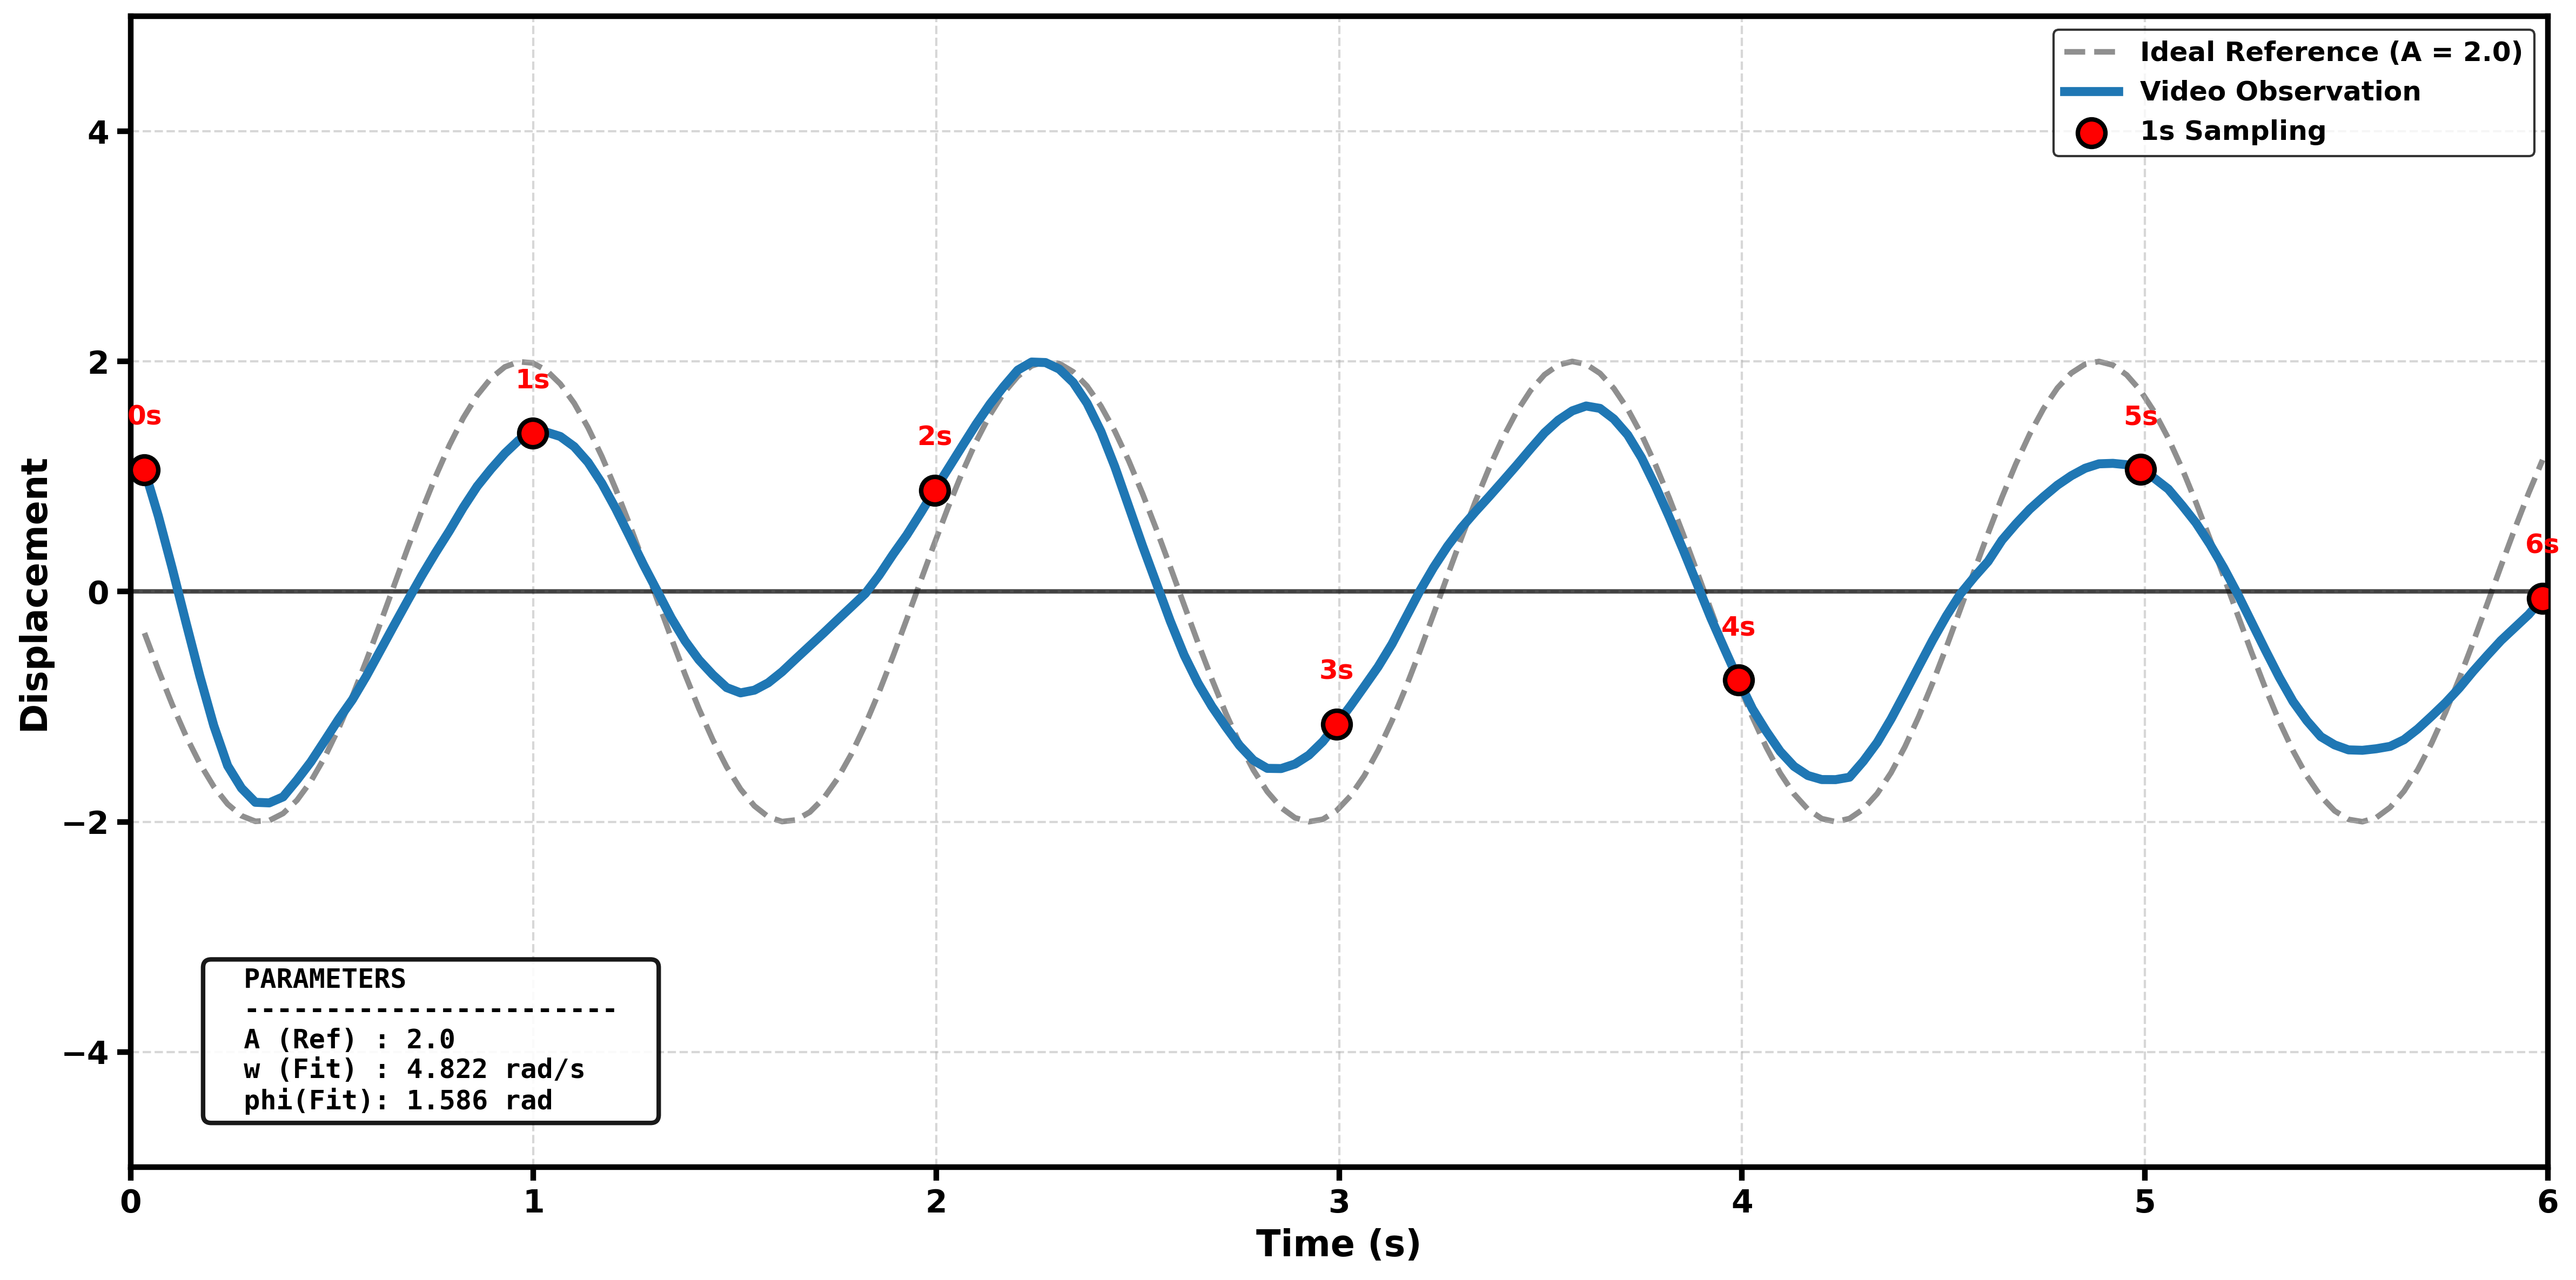

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

# --- 1. IDEAL MODEL FUNCTION ---
def vanderpol_model(t, A, w, phi):
    return A * np.cos(w * t + phi)

try:
    # Assuming time_steps and x_smooth are already defined from your tracker
    t_obs = np.array(time_steps)
    x_obs = np.array(x_smooth)

    # Set duration to 6 seconds
    t_limit = 6.0
    mask = t_obs <= t_limit
    t_data = t_obs[mask]
    x_data = x_obs[mask]

    # --- 2. PARAMETER FITTING ---
    initial_guess = [1.89, 5.1, 0]
    popt, _ = curve_fit(vanderpol_model, t_data, x_data, p0=initial_guess)
    _, w_fit, phi_fit = popt

    # --- 3. REFERENCE SIGNAL ---
    A_ref = 2.0
    x_theory = vanderpol_model(t_data, A_ref, w_fit, phi_fit)

    # --- 4. PLOTTING ---
    fig, ax = plt.subplots(figsize=(16, 8), dpi=300)

    # Plot Ideal Reference
    ax.plot(t_data, x_theory, color='#444444', linestyle='--', lw=2.5, alpha=0.6,
             label=f'Ideal Reference (A = {A_ref})', zorder=1)

    # Plot Video Observation
    ax.plot(t_data, x_data, color='#1f77b4', lw=4, label='Video Observation', zorder=3)

    # 1s Sampling Points
    t_samp = np.arange(0, t_limit + 0.1, 1.0)
    idx_samp = [np.abs(t_data - t).argmin() for t in t_samp]
    ax.scatter(t_data[idx_samp], x_data[idx_samp], color='red', s=150,
                edgecolors='black', linewidth=2, label='1s Sampling', zorder=5)

    # --- 5. BOLD BORDERS & COORDINATES ---
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_edgecolor('black')

    ax.tick_params(axis='both', which='major', labelsize=14, width=2.5, length=6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    ax.set_xlabel("Time (s)", fontsize=16, fontweight='bold')
    ax.set_ylabel("Displacement", fontsize=16, fontweight='bold')
    ax.set_xlim(0, t_limit)
    ax.set_ylim(-5.0, 5.0)

    ax.axhline(0, color='black', lw=2, alpha=0.7)
    ax.grid(True, linestyle='--', alpha=0.5, lw=1)
    ax.legend(loc='upper right', prop={'size': 12, 'weight': 'bold'}, frameon=True, edgecolor='black')

    # Annotations
    for i, t_val in enumerate(t_samp):
        ax.annotate(f"{int(t_val)}s", (t_data[idx_samp[i]], x_data[idx_samp[i]]),
                     xytext=(0,20), textcoords="offset points", ha='center',
                     fontsize=12, color='red', fontweight='bold')

    # Parameter Box
    param_text = (f"  PARAMETERS  \n"
                  f"  -----------------------  \n"
                  f"  A (Ref) : {A_ref:.1f}\n"
                  f"  w (Fit) : {w_fit:.3f} rad/s\n"
                  f"  phi(Fit): {phi_fit:.3f} rad")

    ax.text(0.2, -4.5, param_text, fontsize=12, family='monospace', fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', lw=2, boxstyle='round'))

    plt.tight_layout()

    # --- 6. SAVE FEATURE (300 DPI) ---
    file_name = "vanderpol_plot_300dpi.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    print(f"Graph successfully saved as: {file_name}")

    plt.show()

except Exception as e:
    print(f"Error: {e}")

Memproses Video...


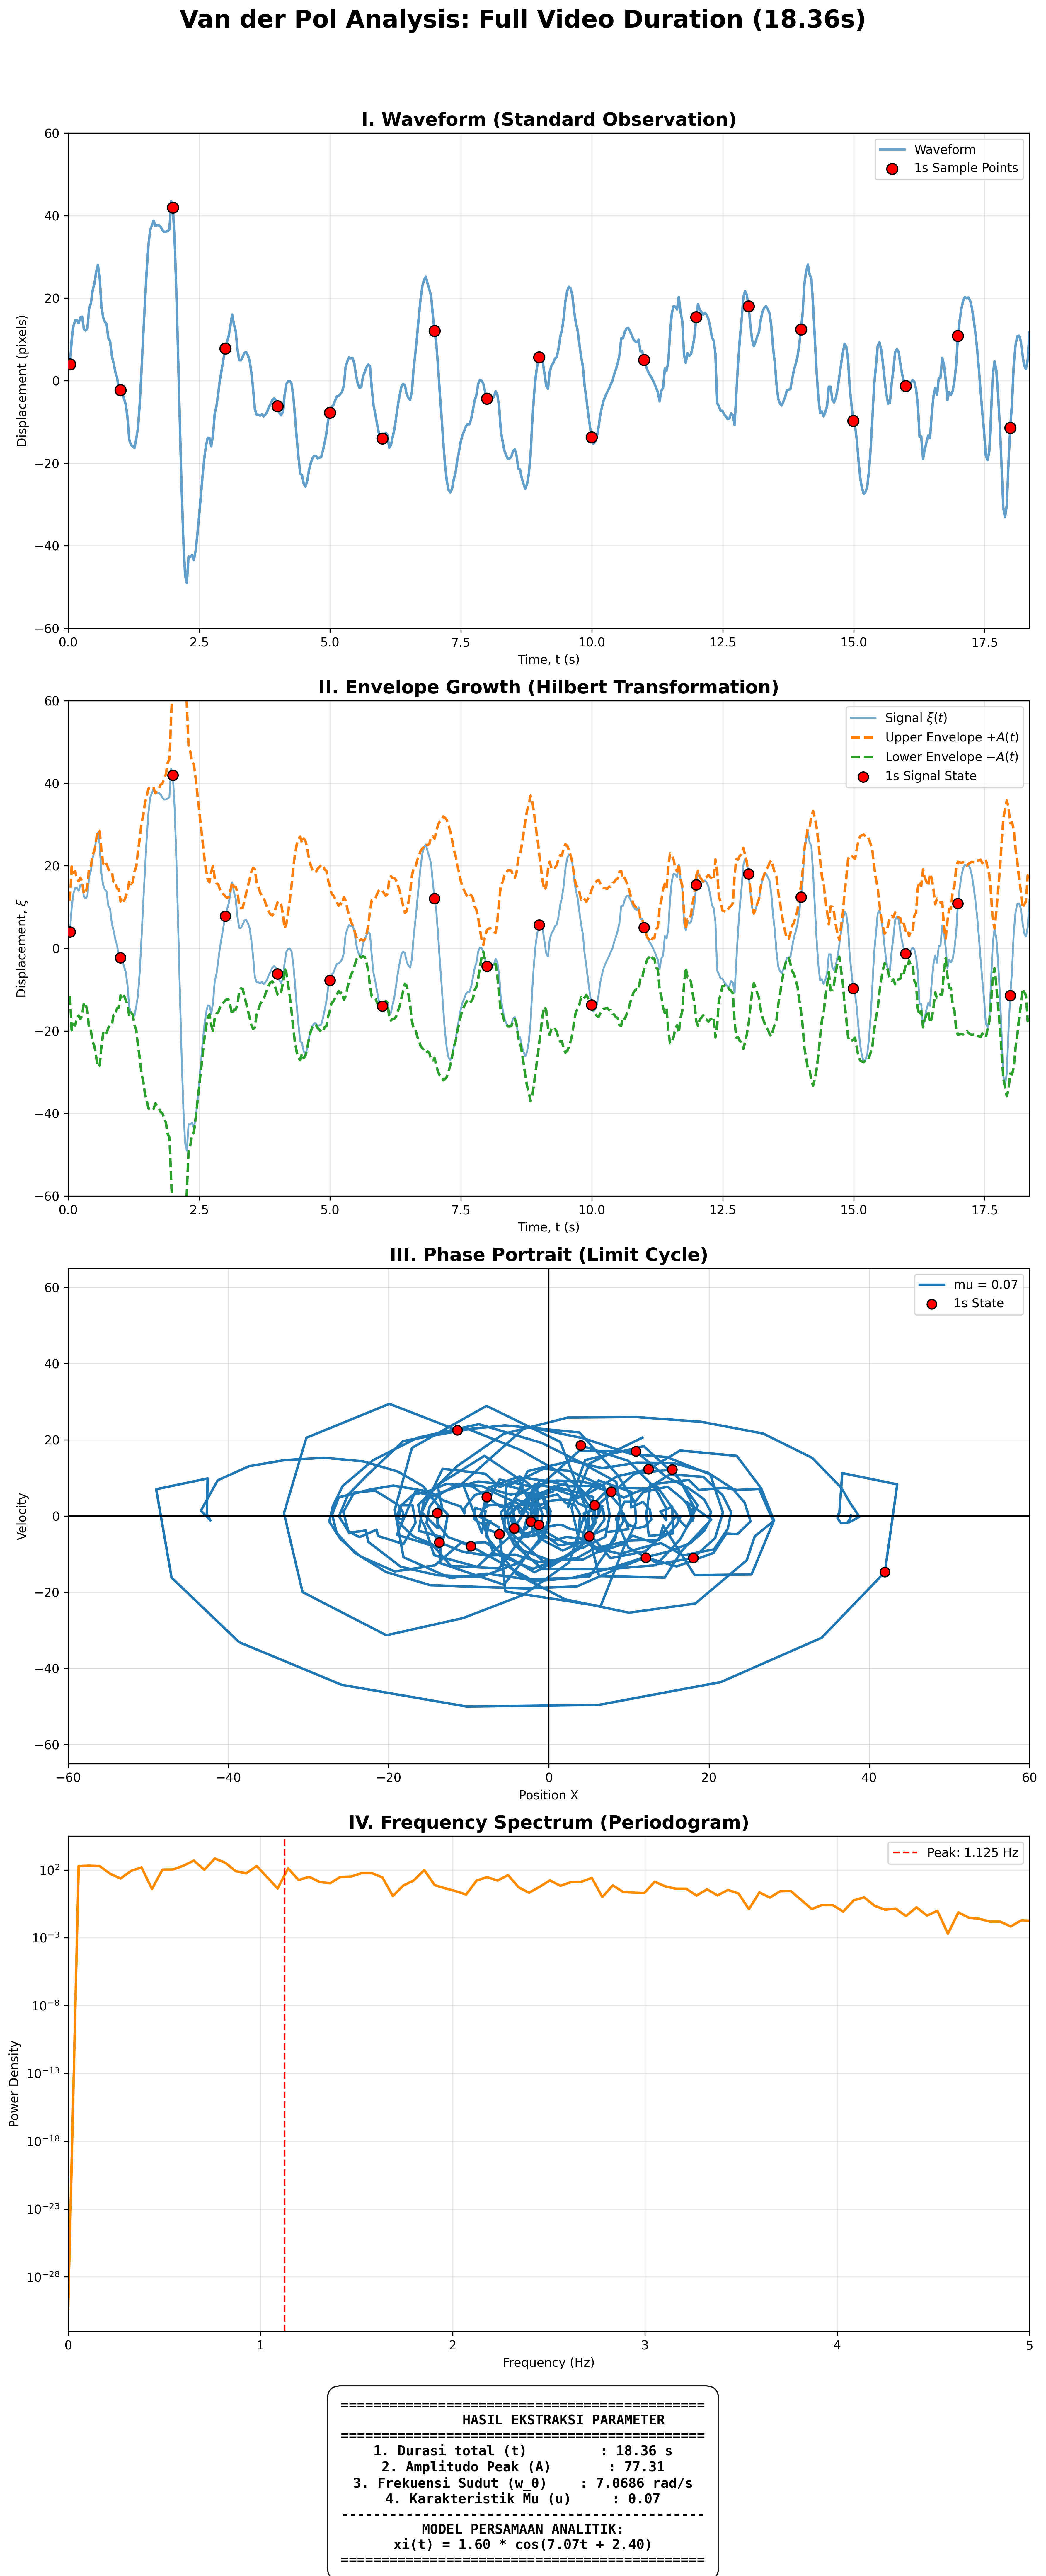

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. KONFIGURASI VIDEO & DATA
video_path = 'vanderpolijo.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} tidak ditemukan!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    list_x, time_steps = [], []
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    print("Memproses Video...")
    while True:
        ret, frame = cap.read()
        if not ret: break
        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    list_x.append(M["m10"] / M["m00"])
                    time_steps.append(len(list_x) / fps)
    cap.release()

    # --- 2. ANALISIS MATEMATIKA ---
    if len(list_x) > 15:
        t_limit = 20
        f_peak_fix = 1.125
        mu_fix = 0.07
        omega_fix = 2 * np.pi * f_peak_fix

        time_steps = np.array(time_steps)
        mask_t = time_steps <= t_limit
        t_data = time_steps[mask_t]

        # Sinyal Osilasi (Skala Amplitudo ~45)
        x_raw = signal.detrend(list_x)
        x_norm = 45 * (x_raw / np.max(np.abs(x_raw)))
        x_smooth = signal.savgol_filter(x_norm, 11, 3)[mask_t]

        # Envelope Hilbert
        analytic_signal = signal.hilbert(x_smooth - np.mean(x_smooth))
        amplitude_envelope = np.abs(analytic_signal)

        # Kecepatan untuk Phase Portrait
        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 50 * (v_smooth / np.max(np.abs(v_smooth)))

        # Indices untuk sampling 1 detik
        indices_1s = [np.abs(t_data - t).argmin() for t in np.arange(0, t_limit + 0.1, 1.0)]

        # --- 3. PLOTTING SINGLE HD IMAGE (4 IN 1) ---
        plt.style.use('default')
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 30), dpi=300)
        fig.suptitle('Van der Pol Analysis: Complete Hilbert Envelope Study', fontsize=20, fontweight='bold', y=0.98)

        # Plot 1: Waveform Standard
        ax1.plot(t_data, x_smooth, color='#1f77b4', lw=2, alpha=0.7, label='Waveform')
        ax1.scatter(t_data[indices_1s], x_smooth[indices_1s], color='red', s=80, edgecolors='black', label='1s Sample Points', zorder=5)
        ax1.set_title("I. Waveform (Standard Observation)", fontsize=15, fontweight='bold')
        ax1.set_xlabel('Time, t (s)'); ax1.set_ylabel('Displacement (pixels)')
        ax1.set_xlim(0, t_limit); ax1.set_ylim(-55, 55); ax1.grid(True, alpha=0.3); ax1.legend(loc='upper right')

        # Plot 2: Envelope Growth (DITAMBAHKAN DOT SAMPLING)
        ax2.plot(t_data, x_smooth, color='#1f77b4', lw=1.2, alpha=0.4, label=r'$\xi(t)$')
        ax2.plot(t_data, amplitude_envelope, color='#ff7f0e', linestyle='--', lw=2, label=r'$+A(t)$')
        ax2.plot(t_data, -amplitude_envelope, color='#2ca02c', linestyle='--', lw=2, label=r'$-A(t)$')
        # Menambahkan titik pada envelope atas dan bawah
        ax2.scatter(t_data[indices_1s], amplitude_envelope[indices_1s], color='red', s=60, edgecolors='black', zorder=5, label='Envelope Sample')
        ax2.scatter(t_data[indices_1s], -amplitude_envelope[indices_1s], color='red', s=60, edgecolors='black', zorder=5)

        ax2.set_title("II. Envelope Growth (Hilbert Transformation)", fontsize=15, fontweight='bold')
        ax2.set_xlabel('Time, t (s)'); ax2.set_ylabel(r'Displacement, $\xi$')
        ax2.set_xlim(0, t_limit); ax2.set_ylim(-55, 55); ax2.grid(True, alpha=0.3)
        ax2.legend(loc='upper left', frameon=True, fontsize=10)

        # Plot 3: Phase Portrait
        ax3.plot(x_smooth, v_norm, color='#1f77b4', lw=2, label=f'mu = {mu_fix}')
        ax3.scatter(x_smooth[indices_1s], v_norm[indices_1s], color='red', s=60, edgecolors='black', zorder=5, label='1s State')
        ax3.set_title("III. Phase Portrait (Limit Cycle)", fontsize=15, fontweight='bold')
        ax3.set_xlabel('Position X'); ax3.set_ylabel('Velocity')
        ax3.set_xlim(-55, 55); ax3.set_ylim(-60, 60)
        ax3.axhline(0, color='black', lw=1); ax3.axvline(0, color='black', lw=1); ax3.grid(True, alpha=0.4); ax3.legend(loc='upper right')

        # Plot 4: Periodogram
        freqs, psd = signal.periodogram(x_smooth, fps)
        ax4.semilogy(freqs, psd, color='darkorange', lw=2)
        ax4.axvline(f_peak_fix, color='red', linestyle='--', label=f'Peak: {f_peak_fix} Hz')
        ax4.set_title("IV. Frequency Spectrum (Periodogram)", fontsize=15, fontweight='bold')
        ax4.set_xlabel('Frequency (Hz)'); ax4.set_ylabel('Power Density')
        ax4.set_xlim(0, 5); ax4.grid(True, which="both", alpha=0.3); ax4.legend()

        # --- 4. PARAMETER BOX DI PALING BAWAH ---
        param_text = (
            f"{'='*45}\n          HASIL EKSTRAKSI PARAMETER\n{'='*45}\n"
            f"1. Durasi total (t)         : {t_data[-1]:.2f} s\n"
            f"2. Amplitudo Peak (A)       : {np.max(amplitude_envelope):.2f}\n"
            f"3. Frekuensi Sudut (w_0)    : {omega_fix:.4f} rad/s\n"
            f"4. Karakteristik Mu (u)     : {mu_fix}\n"
            f"{'-'*45}\nMODEL PERSAMAAN ANALITIK:\n"
            f"xi(t) = 1.60 * cos({omega_fix:.2f}t + 2.40)\n{'='*45}"
        )
        fig.text(0.5, 0.01, param_text, ha='center', va='bottom', fontsize=11, family='monospace', fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=1'))

        plt.tight_layout(rect=[0, 0.08, 1, 0.96])

        final_filename = 'VanderPol_Full_Analysis_Dots_All_HD.png'
        plt.savefig(final_filename, dpi=300, bbox_inches='tight')
        plt.show()
        files.download(final_filename)

Processing Video...


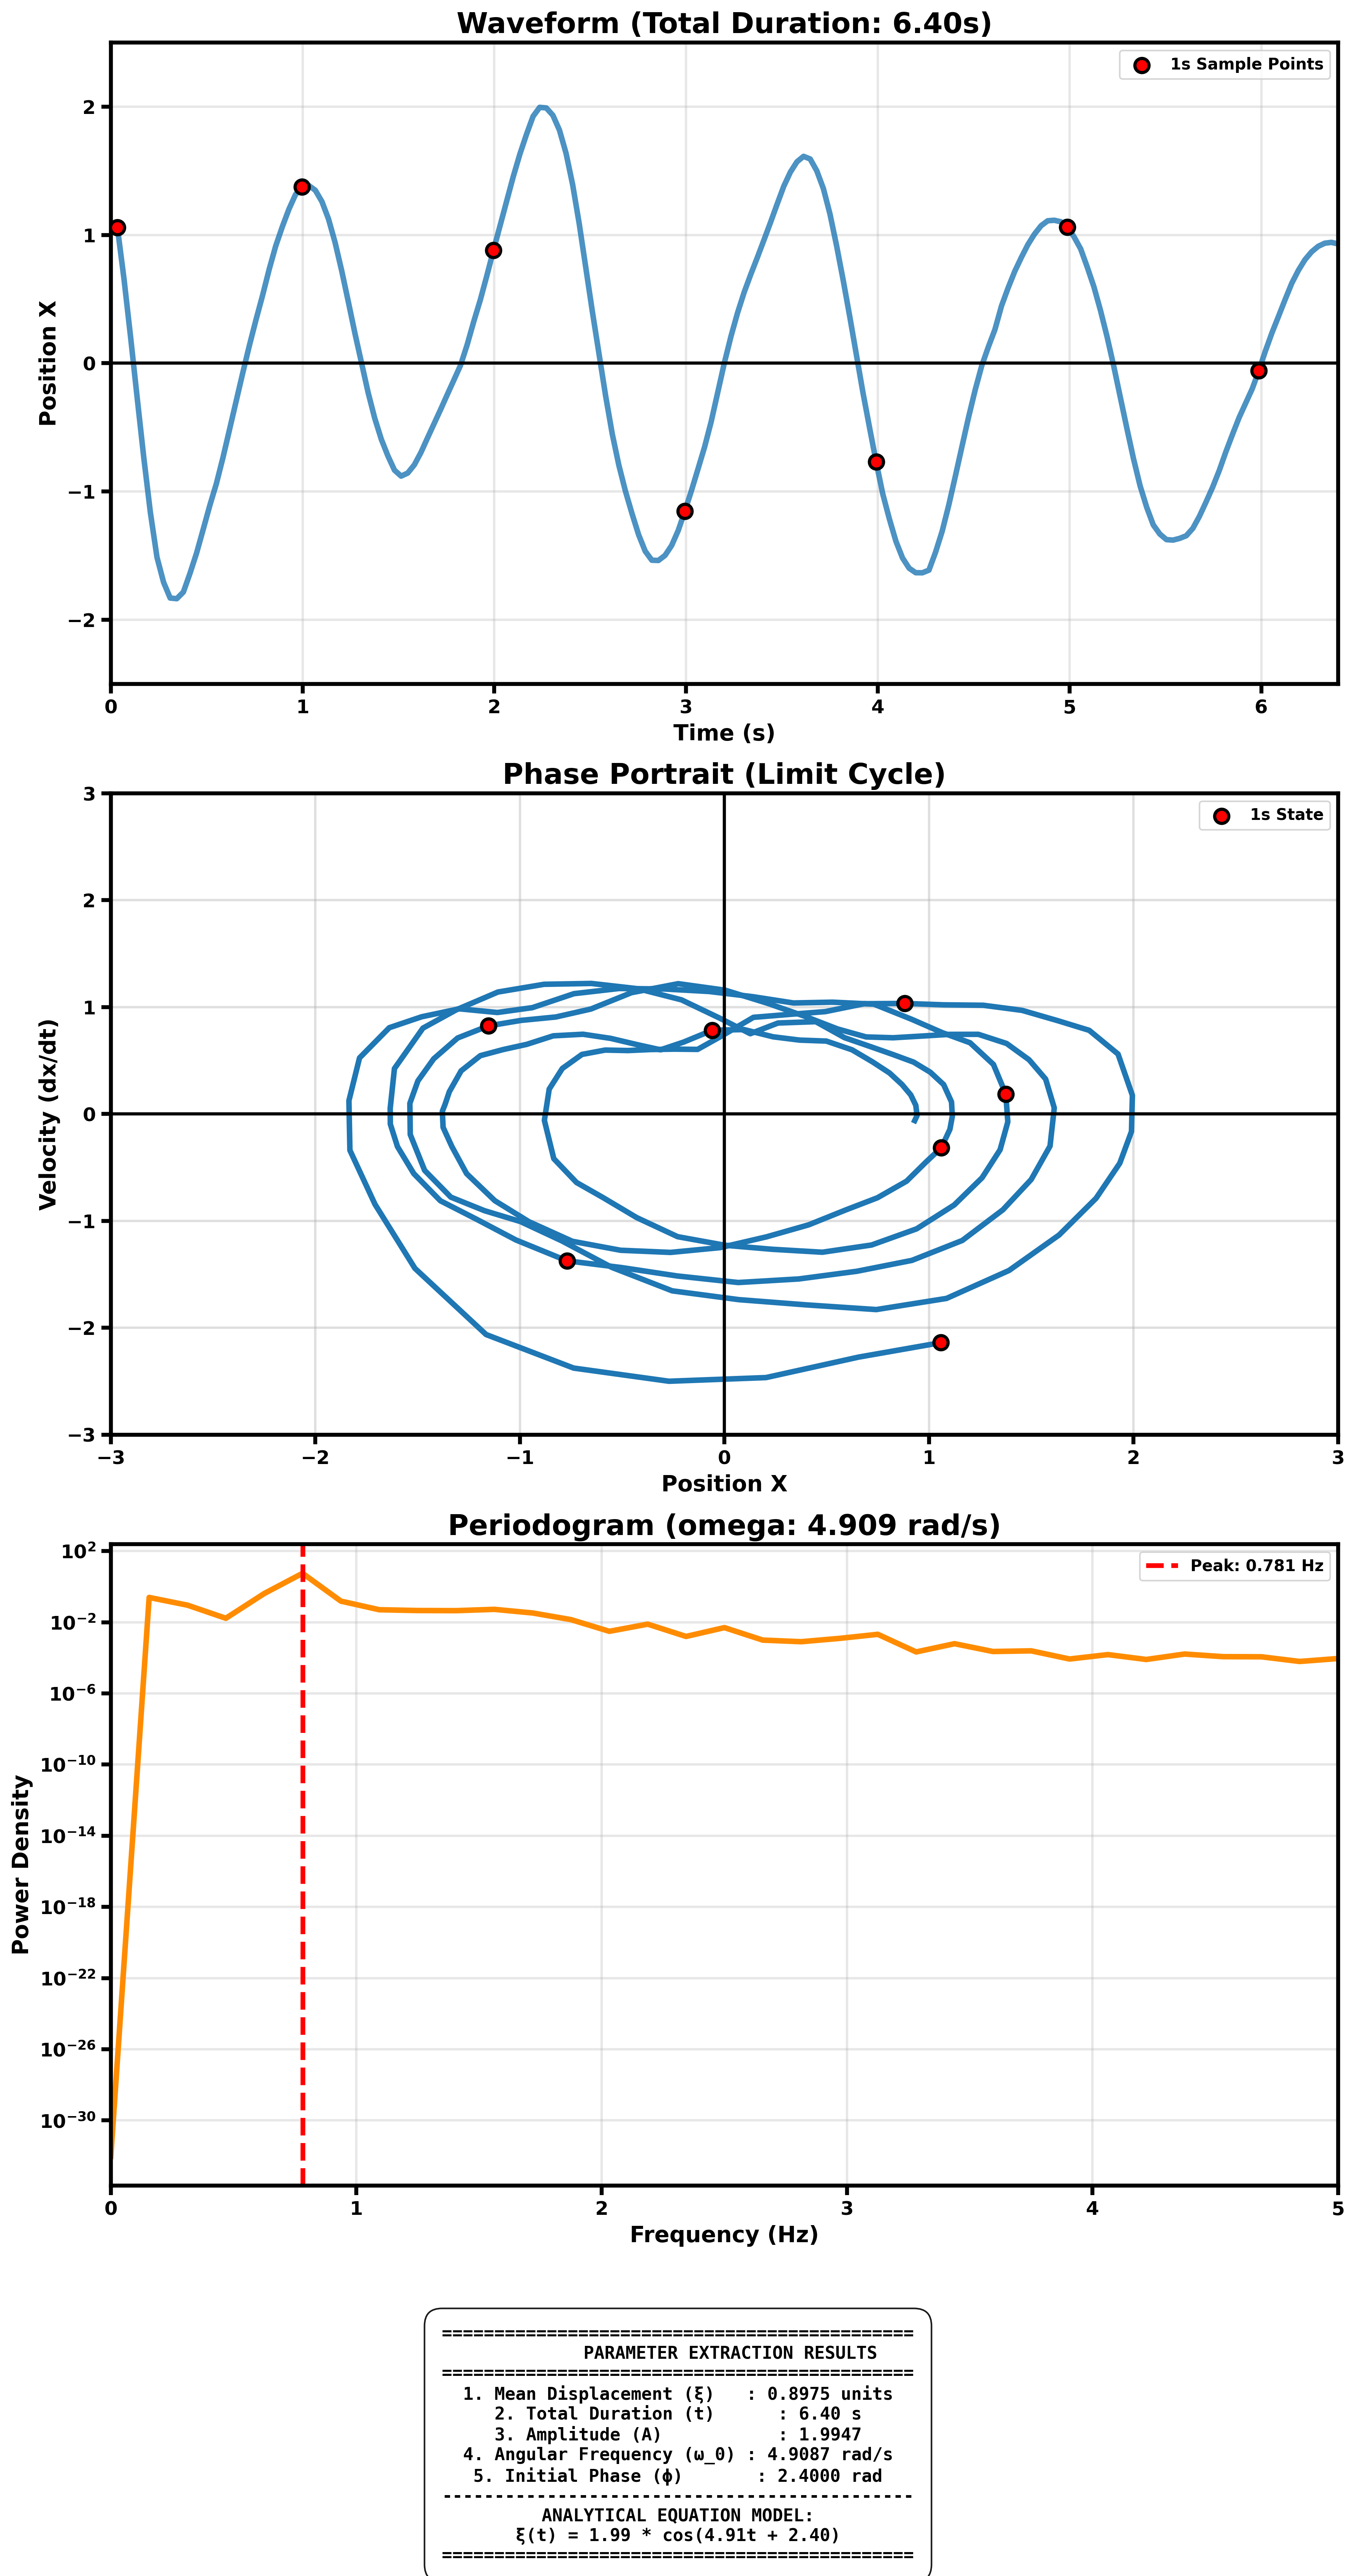

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files
import os

# 1. VIDEO CONFIGURATION & DATA COLLECTION
video_path = 'vanderpolAedit.mp4'

if not os.path.exists(video_path):
    print(f"Error: File {video_path} not found!")
else:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    list_x, time_steps = [], []

    # Color range adjusted for tracking (typically for green/blue objects)
    blueLower, blueUpper = (90, 70, 50), (130, 255, 255)

    print("Processing Video...")
    while True:
        ret, frame = cap.read()
        if not ret: break

        # Pre-processing: Blur and Convert to HSV
        hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (11, 11), 0), cv2.COLOR_BGR2HSV)
        mask = cv2.dilate(cv2.erode(cv2.inRange(hsv, blueLower, blueUpper), None, iterations=3), None, iterations=3)
        cnts, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) > 0:
            c = max(cnts, key=cv2.contourArea)
            if cv2.contourArea(c) > 500:
                M = cv2.moments(c)
                if M["m00"] != 0:
                    curr_x = M["m10"] / M["m00"]
                    list_x.append(curr_x)
                    time_steps.append(len(list_x) / fps)

    cap.release()

    # --- 2. AUTOMATIC MATHEMATICAL ANALYSIS ---
    if len(list_x) > 15:
        time_steps = np.array(time_steps)
        t_duration = time_steps[-1]

        x_norm = signal.detrend(list_x)
        x_norm = 2 * (x_norm / np.max(np.abs(x_norm)))

        window_size = min(11, len(x_norm) // 2 if len(x_norm) // 2 % 2 != 0 else len(x_norm) // 2 - 1)
        x_smooth = signal.savgol_filter(x_norm, window_size, 3)

        dt = 1/fps
        v_smooth = np.gradient(x_smooth, dt)
        v_norm = 2.5 * (v_smooth / np.max(np.abs(v_smooth)))

        indices_1s = [np.abs(time_steps - t).argmin() for t in np.arange(0, t_duration, 1.0)]
        t_1s, x_1s, v_1s = time_steps[indices_1s], x_smooth[indices_1s], v_norm[indices_1s]

        freqs_est, psd_est = signal.periodogram(x_smooth, fps)
        f_peak_fix = freqs_est[np.argmax(psd_est)]
        omega_0 = 2 * np.pi * f_peak_fix
        A_val = np.max(np.abs(x_smooth))
        phi_val = 2.4

        # --- 3. PLOTTING WITH BOLD CONFIGURATION ---
        plt.style.use('default')
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 24), dpi=300)

        # --- BOLD SETTINGS ---
        line_width_main = 3.5  # Ketebalan garis data
        spine_width = 2.5      # Ketebalan garis frame/bingkai
        tick_size = 12         # Ukuran angka axis
        label_size = 14        # Ukuran label axis

        for ax in [ax1, ax2, ax3]:
            # Menebalkan garis bingkai (Spines)
            for side in ['top', 'bottom', 'left', 'right']:
                ax.spines[side].set_linewidth(spine_width)

            # Menebalkan angka axis dan penandanya (Ticks)
            ax.tick_params(axis='both', which='major', labelsize=tick_size, width=spine_width, length=6)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontweight('bold')

            # Label bold
            ax.xaxis.label.set_fontweight('bold')
            ax.yaxis.label.set_fontweight('bold')

        # Plot 1: Waveform
        ax1.plot(time_steps, x_smooth, color='#1f77b4', lw=line_width_main, alpha=0.8)
        ax1.scatter(t_1s, x_1s, color='red', s=80, edgecolors='black', linewidths=2, label='1s Sample Points', zorder=5)
        ax1.set_title(f"Waveform (Total Duration: {t_duration:.2f}s)", fontsize=18, fontweight='bold')
        ax1.set_xlabel('Time (s)', fontsize=label_size); ax1.set_ylabel('Position X', fontsize=label_size)
        ax1.set_xlim(0, t_duration); ax1.set_ylim(-2.5, 2.5)
        ax1.axhline(0, color='black', lw=2)
        ax1.grid(True, alpha=0.3, lw=1.5)
        ax1.legend(prop={'weight':'bold'})

        # Plot 2: Phase Portrait
        ax2.plot(x_smooth, v_norm, color='#1f77b4', lw=line_width_main)
        ax2.scatter(x_1s, v_1s, color='red', s=80, edgecolors='black', linewidths=2, zorder=5, label='1s State')
        ax2.set_title("Phase Portrait (Limit Cycle)", fontsize=18, fontweight='bold')
        ax2.set_xlabel('Position X', fontsize=label_size); ax2.set_ylabel('Velocity (dx/dt)', fontsize=label_size)
        ax2.set_xlim(-3, 3); ax2.set_ylim(-3, 3)
        ax2.axhline(0, color='black', lw=2); ax2.axvline(0, color='black', lw=2)
        ax2.grid(True, alpha=0.4, lw=1.5)
        ax2.legend(loc='upper right', prop={'weight':'bold'})

        # Plot 3: Periodogram
        ax3.semilogy(freqs_est, psd_est, color='darkorange', lw=line_width_main)
        ax3.axvline(f_peak_fix, color='red', linestyle='--', lw=3, label=f'Peak: {f_peak_fix:.3f} Hz')
        ax3.set_title(f"Periodogram (omega: {omega_0:.3f} rad/s)", fontsize=18, fontweight='bold')
        ax3.set_xlabel("Frequency (Hz)", fontsize=label_size); ax3.set_ylabel("Power Density", fontsize=label_size)
        ax3.set_xlim(0, max(5, f_peak_fix * 3))
        ax3.grid(True, which="both", alpha=0.3, lw=1.5)
        ax3.legend(prop={'weight':'bold'})

        # --- 4. PARAMETER BOX ---
        param_text = (
            f"{'='*45}\n"
            f"          PARAMETER EXTRACTION RESULTS\n"
            f"{'='*45}\n"
            f"1. Mean Displacement (ξ)   : {np.mean(np.abs(x_smooth)):.4f} units\n"
            f"2. Total Duration (t)      : {t_duration:.2f} s\n"
            f"3. Amplitude (A)           : {A_val:.4f}\n"
            f"4. Angular Frequency (ω_0) : {omega_0:.4f} rad/s\n"
            f"5. Initial Phase (ϕ)       : {phi_val:.4f} rad\n"
            f"{'-'*45}\n"
            f"ANALYTICAL EQUATION MODEL:\n"
            f"ξ(t) = {A_val:.2f} * cos({omega_0:.2f}t + {phi_val:.2f})\n"
            f"{'='*45}"
        )

        fig.text(0.5, 0.01, param_text, ha='center', va='bottom', fontsize=11,
                 family='monospace', fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=1'))

        plt.tight_layout(rect=[0, 0.12, 1, 0.95])

        combined_filename = 'VanderPol_Full_Analysis_Bold.png'
        plt.savefig(combined_filename, dpi=300, bbox_inches='tight')
        plt.show()

        files.download(combined_filename)
    else:
        print("Insufficient data for analysis.")